## 9.4 实战案例27：使用DeepSeek辅助中国铝业股票价格和RSI交易信号分析

### 9.4.1 步骤1：数据采集与预处理

#### 1.加载数据

In [1]:
import pandas as pd

# 读取中国铝业的股票历史交易数据
df = pd.read_excel('data/中国铝业.xlsx')
df # 打印数据集df

,Date,Open,Close,High,Low,Volume
0,2021-07-23,6.22,6.28,6.13,6.41,4702113
1,2021-07-22,5.84,6.17,5.83,6.26,-83869716
2,2021-07-21,5.75,5.81,5.66,NaN,2383230
3,2021-07-20,5.61,NaN,5.51,5.69,2401534
4,2021-07-19,NaN,5.82,5.74,6.05,3815858
...,...,...,...,...,...,...
75,2021-04-02,3.83,3.81,3.76,3.86,825597
76,2021-04-01,3.79,3.83,3.73,3.85,901736
77,2021-03-31,3.76,3.77,3.71,3.79,1066106
78,2021-03-30,3.82,3.82,3.73,3.86,1042171


#### 2.检查缺失值

In [2]:
# 查看数据基本信息，检查缺失值情况
print("\n缺失值统计：")
print(df.isnull().sum())


缺失值统计：
Date      0
Open      1
Close     1
High      0
Low       1
Volume    0
dtype: int64


#### 3.处理缺失值

In [3]:
# 使用前向填充来处理缺失值
df[['Open', 'Close', 'Low']] = df[['Open', 'Close', 'Low']].ffill()
df # 打印数据集df

,Date,Open,Close,High,Low,Volume
0,2021-07-23,6.22,6.28,6.13,6.41,4702113
1,2021-07-22,5.84,6.17,5.83,6.26,-83869716
2,2021-07-21,5.75,5.81,5.66,6.26,2383230
3,2021-07-20,5.61,5.81,5.51,5.69,2401534
4,2021-07-19,5.61,5.82,5.74,6.05,3815858
...,...,...,...,...,...,...
75,2021-04-02,3.83,3.81,3.76,3.86,825597
76,2021-04-01,3.79,3.83,3.73,3.85,901736
77,2021-03-31,3.76,3.77,3.71,3.79,1066106
78,2021-03-30,3.82,3.82,3.73,3.86,1042171


#### 4.检查和异常值

In [4]:
negative_volume = df[df['Volume'] < 0]
if not negative_volume.empty:
    print("存在异常值：成交量为负数")
    print(negative_volume)

存在异常值：成交量为负数
        Date  Open  Close  High   Low    Volume
1 2021-07-22  5.84   6.17  5.83  6.26 -83869716


#### 5.处理异常值

In [5]:
# 将成交量为负数的异常值替换为 NaN
df.loc[df['Volume'] < 0, 'Volume'] = None
# 使用前向填充处理 NaN 值
df['Volume'] = df['Volume'].ffill()
df # 打印数据集df

,Date,Open,Close,High,Low,Volume
0,2021-07-23,6.22,6.28,6.13,6.41,4702113.0
1,2021-07-22,5.84,6.17,5.83,6.26,4702113.0
2,2021-07-21,5.75,5.81,5.66,6.26,2383230.0
3,2021-07-20,5.61,5.81,5.51,5.69,2401534.0
4,2021-07-19,5.61,5.82,5.74,6.05,3815858.0
...,...,...,...,...,...,...
75,2021-04-02,3.83,3.81,3.76,3.86,825597.0
76,2021-04-01,3.79,3.83,3.73,3.85,901736.0
77,2021-03-31,3.76,3.77,3.71,3.79,1066106.0
78,2021-03-30,3.82,3.82,3.73,3.86,1042171.0


#### 6.按日期排序

In [6]:
# 确保日期列是日期格式
df['Date'] = pd.to_datetime(df['Date'])
# 按日期升序排序
df = df.sort_values(by='Date')
df # 打印数据集df

,Date,Open,Close,High,Low,Volume
79,2021-03-29,3.87,3.83,3.81,3.90,1253976.0
78,2021-03-30,3.82,3.82,3.73,3.86,1042171.0
77,2021-03-31,3.76,3.77,3.71,3.79,1066106.0
76,2021-04-01,3.79,3.83,3.73,3.85,901736.0
75,2021-04-02,3.83,3.81,3.76,3.86,825597.0
...,...,...,...,...,...,...
4,2021-07-19,5.61,5.82,5.74,6.05,3815858.0
3,2021-07-20,5.61,5.81,5.51,5.69,2401534.0
2,2021-07-21,5.75,5.81,5.66,6.26,2383230.0
1,2021-07-22,5.84,6.17,5.83,6.26,4702113.0


### 9.4.2 步骤2：计算RSI指标

#### 计算 RSI 指标的函数

In [7]:
import pandas as pd

# 计算 RSI 指标的函数
def calculate_rsi(data, window=14):                # 定义函数，window 默认值为14，即14天计算周期
    # 计算每日收盘价的变动
    delta = data['Close'].diff()                   # 计算每日的价格变化（收盘价的差值）
    
    # 创建 Gain 和 Loss 列，分别记录上涨和下跌的幅度
    gain = delta.copy()                            # 创建 gain 列，复制 delta 的数据
    loss = delta.copy()                            # 创建 loss 列，复制 delta 的数据
    
    # 如果上涨幅度为负数，则设为0（因为只有上涨才算 Gain）
    gain[gain < 0] = 0                             # 所有负数的 Gain 设置为 0
    
    # 如果下跌幅度为正数，则设为0（因为只有下跌才算 Loss）
    loss[loss > 0] = 0                             # 所有正数的 Loss 设置为 0
    
    # 计算14天内的平均涨幅
    avg_gain = gain.rolling(window).mean()         # 计算过去14天内平均的涨幅
    
    # 计算14天内的平均损失，损失为负值取绝对值
    avg_loss = abs(loss.rolling(window).mean())    # 计算过去14天内平均的损失（取绝对值）
    
    # 计算相对强度（RS）
    rs = avg_gain / avg_loss                       # 计算相对强度（RS）= 平均涨幅 / 平均损失
    
    # 根据 RS 计算 RSI 指标
    rsi = 100 - (100 / (1 + rs))                   # 计算 RSI = 100 - (100 / (1 + RS))
    
    return rsi                                     # 返回计算得到的 RSI


##### 计算 RSI（14天周期）

In [8]:
# 计算 RSI（14天周期）
df['RSI'] = calculate_rsi(df)
df # 打印数据集df

,Date,Open,Close,High,Low,Volume,RSI
79,2021-03-29,3.87,3.83,3.81,3.90,1253976.0,NaN
78,2021-03-30,3.82,3.82,3.73,3.86,1042171.0,NaN
77,2021-03-31,3.76,3.77,3.71,3.79,1066106.0,NaN
76,2021-04-01,3.79,3.83,3.73,3.85,901736.0,NaN
75,2021-04-02,3.83,3.81,3.76,3.86,825597.0,NaN
...,...,...,...,...,...,...,...
4,2021-07-19,5.61,5.82,5.74,6.05,3815858.0,66.310160
3,2021-07-20,5.61,5.81,5.51,5.69,2401534.0,64.245810
2,2021-07-21,5.75,5.81,5.66,6.26,2383230.0,71.875000
1,2021-07-22,5.84,6.17,5.83,6.26,4702113.0,76.683938


### 9.4.3 步骤3：初始策略规则的制定

#### 设置买入和卖出条件的函数

In [9]:
def define_strategy_rules(df, rsi_buy=30, rsi_sell=70, ma_window=50, stop_loss=0.05, take_profit=0.10):					
    """
    定义初步策略规则，包括：
      - 买入条件：RSI 小于 rsi_buy 且成交量大于过去14日的平均成交量；
      - 卖出条件：RSI 大于 rsi_sell 或当前价格跌破 ma_window 日均线；
      - 止损规则：买入价格下跌超过 stop_loss 时触发；
      - 止盈规则：买入价格上涨超过 take_profit 时触发。
      
    参数：
      df: 包含股票数据的 DataFrame，必须包含 'Close', 'Volume' 和 'RSI' 列
      rsi_buy: 买入时的 RSI 阈值（默认 30）
      rsi_sell: 卖出时的 RSI 阈值（默认 70）
      ma_window: 均线计算窗口（默认 50 日）
      stop_loss: 止损比例（默认 5%）
      take_profit: 止盈比例（默认 10%）
      
    返回：
      添加了策略规则（信号和参数）的 DataFrame
    """
    # 计算 ma_window 日均线（例如 50 日均线）
    df['MA50'] = df['Close'].rolling(window=ma_window).mean()
    
    # 买入条件：RSI 小于 rsi_buy 且当前成交量大于过去14日的平均成交量
    df['Buy Signal'] = (df['RSI'] < rsi_buy) & (df['Volume'] > 
                                                df['Volume'].rolling(window=14).mean())
    
    # 卖出条件：RSI 大于 rsi_sell 或当前价格跌破 MA50
    df['Sell Signal'] = (df['RSI'] > rsi_sell) | (df['Close'] < df['MA50'])
        # 记录止损和止盈参数（供回测时使用）
    df['Stop Loss'] = stop_loss
    df['Take Profit'] = take_profit
    
    return df

### 9.4.4 步骤4：生成买入和卖出信号

In [10]:
# 计算 RSI
df['RSI'] = calculate_rsi(df)

# 生成买入和卖出信号
df_signals = define_strategy_rules(df)
# 查看买入和卖出信号
df_signals  # 打印数据集df_signals 

,Date,Open,Close,High,Low,Volume,RSI,MA50,Buy Signal,Sell Signal,Stop Loss,Take Profit
79,2021-03-29,3.87,3.83,3.81,3.90,1253976.0,NaN,NaN,False,False,0.05,0.1
78,2021-03-30,3.82,3.82,3.73,3.86,1042171.0,NaN,NaN,False,False,0.05,0.1
77,2021-03-31,3.76,3.77,3.71,3.79,1066106.0,NaN,NaN,False,False,0.05,0.1
76,2021-04-01,3.79,3.83,3.73,3.85,901736.0,NaN,NaN,False,False,0.05,0.1
75,2021-04-02,3.83,3.81,3.76,3.86,825597.0,NaN,NaN,False,False,0.05,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...
4,2021-07-19,5.61,5.82,5.74,6.05,3815858.0,66.310160,5.3220,False,False,0.05,0.1
3,2021-07-20,5.61,5.81,5.51,5.69,2401534.0,64.245810,5.3226,False,False,0.05,0.1
2,2021-07-21,5.75,5.81,5.66,6.26,2383230.0,71.875000,5.3232,False,True,0.05,0.1
1,2021-07-22,5.84,6.17,5.83,6.26,4702113.0,76.683938,5.3296,False,True,0.05,0.1


### 9.4.5 步骤5：绘制RSI曲线与交易信号

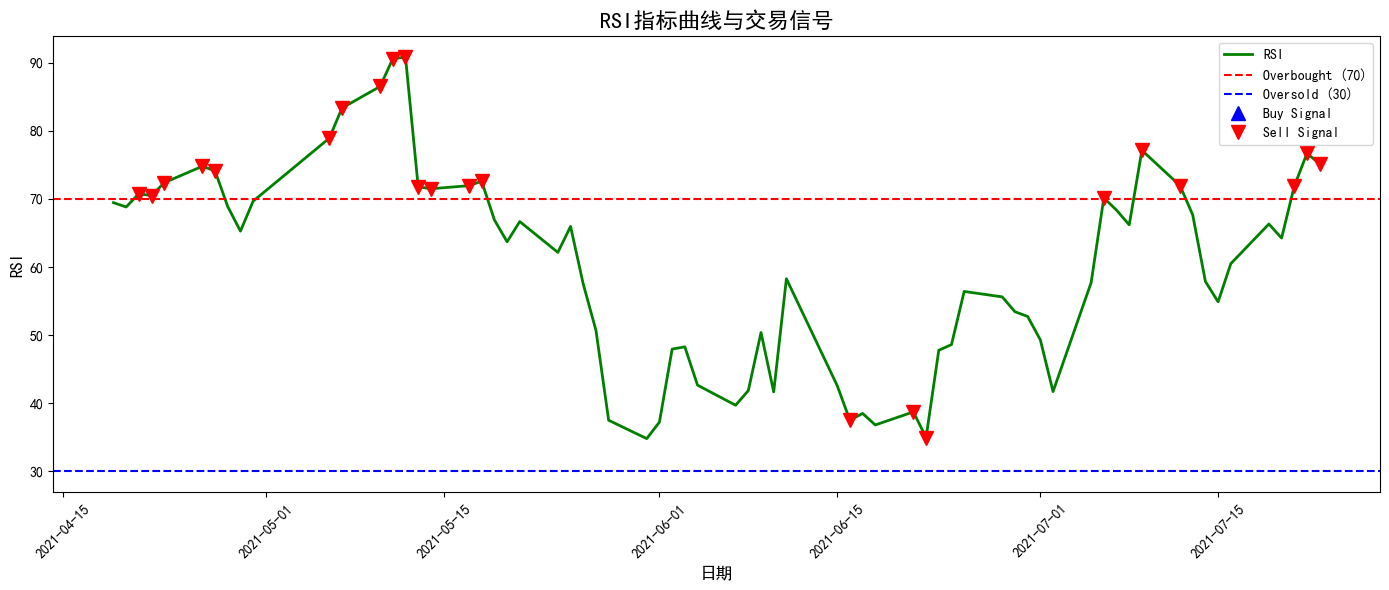

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False  # 设置负号显示
import matplotlib.pyplot as plt

def plot_rsi_and_signals(df):
    plt.figure(figsize=(14, 6))
    
    # 绘制 RSI 曲线
    plt.plot(df['Date'], df['RSI'], label='RSI', color='green', linewidth=2)
    
    # 绘制超买超卖水平线
    plt.axhline(y=70, color='red', linestyle='--', label='Overbought (70)')
    plt.axhline(y=30, color='blue', linestyle='--', label='Oversold (30)')
    
    # 标记买入信号：在 RSI 曲线上用向上箭头标记
    buy_signals = df[df['Buy Signal'] == True]
    plt.plot(buy_signals['Date'], buy_signals['RSI'], '^', markersize=10, color='blue', label='Buy Signal')
    
    # 标记卖出信号：在 RSI 曲线上用向下箭头标记
    sell_signals = df[df['Sell Signal'] == True]
    plt.plot(sell_signals['Date'], sell_signals['RSI'], 'v', markersize=10, color='red', label='Sell Signal')
    
    plt.title('RSI指标曲线与交易信号', fontsize=16)
    plt.xlabel('日期', fontsize=12)
    plt.ylabel('RSI', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 调用函数绘制图表
plot_rsi_and_signals(df_signals )


### 9.4.6 步骤6：使用模拟回测验证策略

In [12]:
import pandas as pd
# 定义回测
def backtest(df):
    # 初始化账户信息
    df['Position'] = 0
    df['Cash'] = 100000.0  # 初始现金，设置为 float
    df['Shares'] = 0       # 初始持仓数量
    df['Portfolio Value'] = df['Cash']  # 初始总资产
    initial_cash = df['Cash'].iloc[0]

    # 遍历数据，根据交易信号更新持仓和账户
    for i in range(1, len(df)):
        # 买入操作：如果买入信号为 True 且前一日没有持仓
        if df['Buy Signal'].iloc[i] and df['Position'].iloc[i-1] == 0:
            df.loc[i, 'Shares'] = df['Cash'].iloc[i-1] // df['Close'].iloc[i]  # 计算可以买入多少股
            df.loc[i, 'Cash'] = df['Cash'].iloc[i-1] - df.loc[i, 'Shares'] * df['Close'].iloc[i]
            df.loc[i, 'Position'] = 1  # 持仓状态变为 1

        # 卖出操作：如果卖出信号为 True 且前一日持有股票
        elif df['Sell Signal'].iloc[i] and df['Position'].iloc[i-1] == 1:
            df.loc[i, 'Cash'] = df['Cash'].iloc[i-1] + df['Shares'].iloc[i-1] * df['Close'].iloc[i]
            df.loc[i, 'Shares'] = 0
            df.loc[i, 'Position'] = 0  # 平仓后持仓状态变为 0

        # 计算每日总资产（现金 + 股票市值）
        df.loc[i, 'Portfolio Value'] = df['Cash'].iloc[i] + df['Shares'].iloc[i] * df['Close'].iloc[i]

    # 计算总收益率
    total_return = (df['Portfolio Value'].iloc[-1] - initial_cash) / initial_cash
    print(f"策略总收益: {total_return * 100:.2f}%")
    return df

# 运行回测
backtest_results = backtest(df)

策略总收益: 0.00%


#### 可视化回测结果

In [13]:
# 计算策略总收益
def backtest(df):
    # 初始化持仓，现金等信息
    df['Position'] = 0
    df['Cash'] = 100000.0  # 初始现金（使用浮动类型）
    df['Portfolio Value'] = df['Cash']  # 初始总资产等于现金
    df['Shares'] = 0  # 持仓数

    # 逐行遍历数据，根据信号更新持仓
    for i in range(1, len(df)):
        # 如果买入信号为True，则买入
        if df['Buy Signal'].iloc[i]:
            df.loc[i, 'Shares'] = df['Cash'].iloc[i-1] // df['Close'].iloc[i]
            df.loc[i, 'Cash'] = df['Cash'].iloc[i-1] - df.loc[i, 'Shares'] * df['Close'].iloc[i]
        # 如果卖出信号为True，则卖出
        elif df['Sell Signal'].iloc[i]:
            df.loc[i, 'Cash'] = df['Cash'].iloc[i-1] + df['Shares'].iloc[i-1] * df['Close'].iloc[i]
            df.loc[i, 'Shares'] = 0

        # 计算持仓的当前总值（确保为浮动类型）
        df.loc[i, 'Portfolio Value'] = float(df['Cash'].iloc[i]) + float(df['Shares'].iloc[i]) * float(df['Close'].iloc[i])
        
    # 计算总收益
    total_return = (df['Portfolio Value'].iloc[-1] - df['Portfolio Value'].iloc[0]) / df['Portfolio Value'].iloc[0]
    
    # 输出总收益
    print(f"策略总收益: {total_return * 100:.2f}%")
    
    # 返回回测结果
    return df

# 调用回测函数
backtest_results = backtest(df)


策略总收益: 0.00%


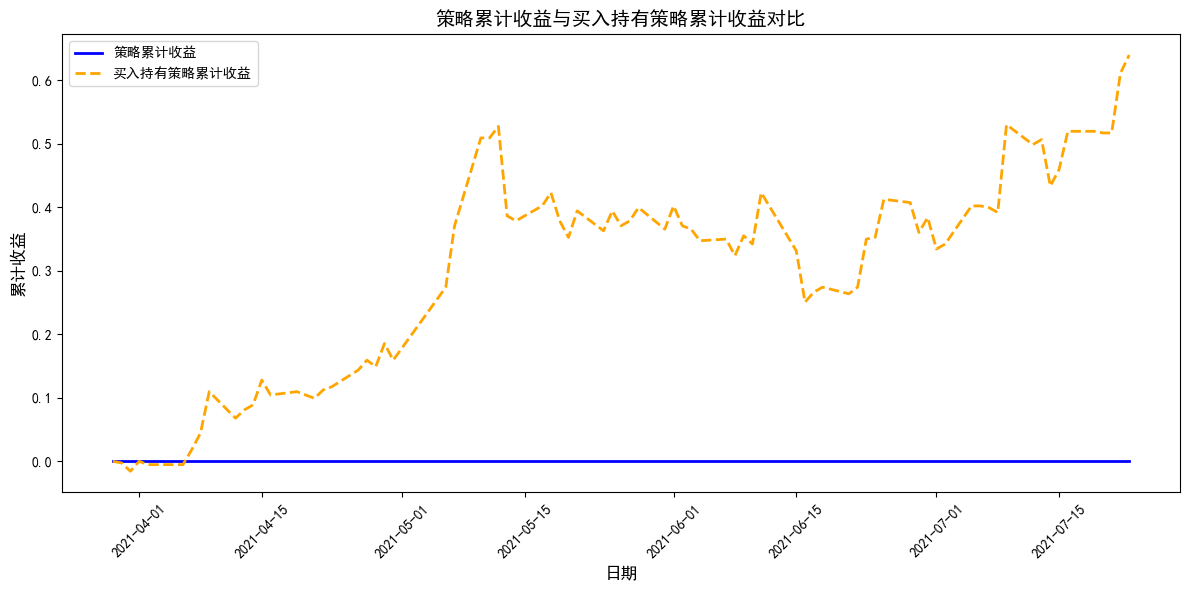

In [14]:
plt.rcParams['font.family'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False  # 设置负号显示

import matplotlib.pyplot as plt

def plot_backtest_results(df):
    # 计算策略的累计收益
    df['Strategy Return'] = (df['Portfolio Value'] / df['Portfolio Value'].iloc[0]) - 1

    # 计算买入持有策略的累计收益
    df['Buy and Hold Return'] = (df['Close'] / df['Close'].iloc[0]) - 1
    
    # 绘制图表
    plt.figure(figsize=(12, 6))
    plt.plot(df['Date'], df['Strategy Return'], label='策略累计收益', color='blue', linewidth=2)
    plt.plot(df['Date'], df['Buy and Hold Return'], label='买入持有策略累计收益', color='orange', linestyle='--', linewidth=2)
    
    # 添加标题和标签
    plt.title('策略累计收益与买入持有策略累计收益对比', fontsize=14)
    plt.xlabel('日期', fontsize=12)
    plt.ylabel('累计收益', fontsize=12)
    
    # 添加图例
    plt.legend()
    
    # 显示图表
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 调用可视化函数
plot_backtest_results(backtest_results)
